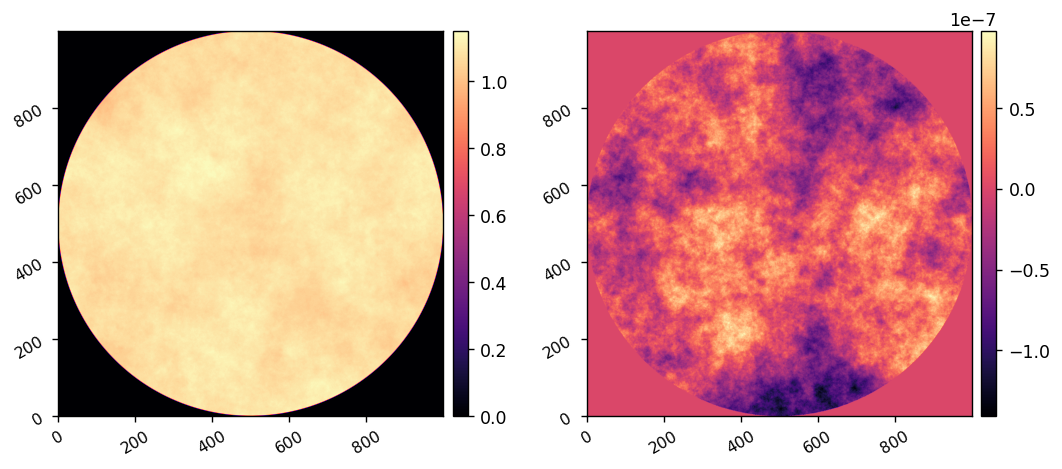

In [3]:
import numpy as np
import astropy.units as u
from astropy.io import fits
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle, Circle
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
from scipy.optimize import minimize

import poppy
import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import warnings
warnings.filterwarnings("ignore")

from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc.imshows import imshow1, imshow2, imshow3
from scoob_llowfsc import utils
from scoob_llowfsc import iefc
import scoob_llowfsc.scoob_model as scoobm

wavelength_c = 633e-9

wfe_amp = utils.load_fits('example_wfe_amp.fits')
wfe_opd = utils.load_fits('example_wfe_opd.fits')
imshow2(wfe_amp, wfe_opd)

In [15]:
reload(scoobm)
M = scoobm.single(
    # dm_ref=dm_flat,
)
M.AMP = wfe_amp
M.OPD = wfe_opd 


1.0
(952,) <class 'numpy.ndarray'>


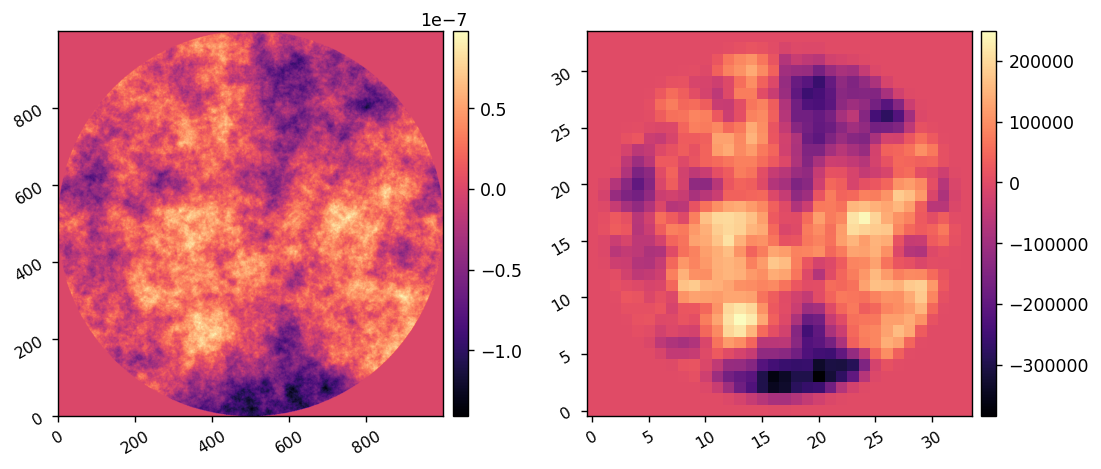

In [17]:
def val_and_grad(
        del_acts, 
        M, 
        # OPD, 
        current_acts=np.zeros((M.Nact,M.Nact)) 
    ):

    del_acts = xp.array(del_acts)
    del_command = xp.zeros((M.Nact, M.Nact))
    del_command[M.dm_mask] = xp.array(del_acts)

    current_acts = xp.array(current_acts)

    dm_command = current_acts + del_command
    dm_mft = M.Mx@dm_command@M.My
    dm_surf_fft = M.inf_fun_fft * dm_mft
    dm_surf = xp.fft.fftshift(xp.fft.ifft2(xp.fft.ifftshift(dm_surf_fft,))).real
    dm_surf = utils.pad_or_crop(dm_surf, M.npix)

    OPD = xp.array(M.OPD)
    opd_l2norm = OPD[M.BAP_MASK].dot(OPD[M.BAP_MASK])
    total_opd =  OPD + 2*dm_surf
    J = total_opd[M.BAP_MASK].dot(total_opd[M.BAP_MASK]) / opd_l2norm
    print(J)

    masked_total = M.APERTURE * total_opd
    dJ_dOPD = 2 * (masked_total) / opd_l2norm

    dJ_dS_DM = utils.pad_or_crop(dJ_dOPD, M.Nsurf)
    x2_bar = xp.fft.fftshift(xp.fft.fft2(xp.fft.ifftshift(dJ_dS_DM)))
    x1_bar = x2_bar * M.inf_fun_fft.conj()
    dJ_dA1 = M.Mx_back@x1_bar@M.My_back / ( M.Nsurf * M.Nact * M.Nact )

    dJ_dA = dJ_dA1[M.dm_mask].real

    return ensure_np_array(J), ensure_np_array(dJ_dA)

del_acts = xp.zeros(M.Nacts)
J0, dJ_dA = val_and_grad(del_acts, M)
print(dJ_dA.shape, type(dJ_dA))

dm_grad = xp.zeros((M.Nact, M.Nact))
dm_grad[M.dm_mask] = xp.array(dJ_dA)
imshow2(M.OPD, dm_grad)

1.0
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =          952     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  3.84797D+05
10852740504432.752
0.6184667542815058

At iterate    1    f=  6.18467D-01    |proj g|=  2.92714D+05
0.1214518175879487

At iterate    2    f=  1.21452D-01    |proj g|=  3.13551D+04
0.11068643875784366

At iterate    3    f=  1.10686D-01    |proj g|=  2.47685D+04
0.09787425795496808

At iterate    4    f=  9.78743D-02    |proj g|=  1.47045D+04
0.09624830189820885

At iterate    5    f=  9.62483D-02    |proj g|=  2.09979D+04
0.09485764196024911

At iterate    6    f=  9.48576D-02    |proj g|=  8.35954D+03
0.09410167972880211

At iterate    7    f=  9.41017D-02    |proj g|=  5.50005D+03
0.09362471829881773

At iterate    8    f=  9.36247D-02    |proj g|=  4.46123D+03
0.09339845515083992

At iterate    9    f=  9.33985D-02    |proj g|=  8.74423D+03
0.0929125889

 This problem is unconstrained.


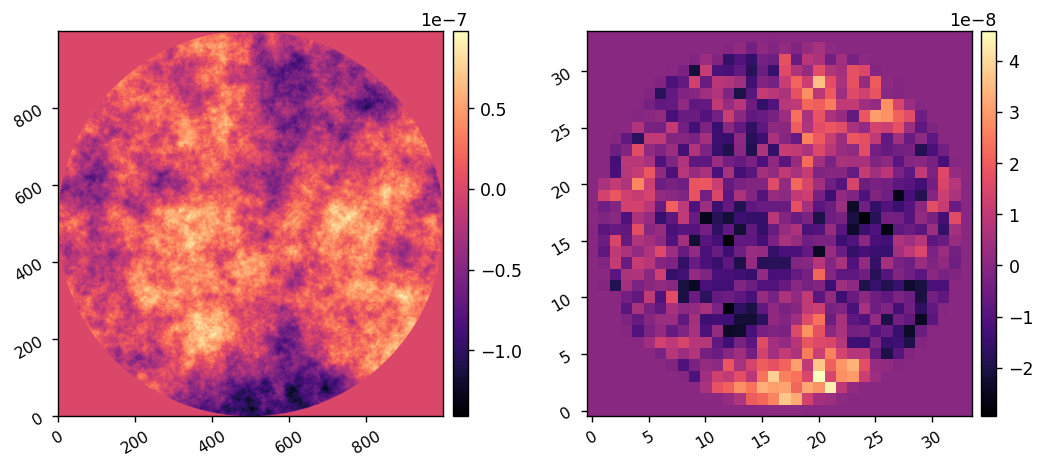

In [19]:
bfgs_tol = 1e-4
options = {
    'disp':True, 
    # 'maxiter':30,
    # 'maxls':100, # default is 20
    # 'ftol':1e-6, 
    # 'gtol':1e-6,
}
del_acts0 = np.zeros(M.Nacts)
res = minimize(
    val_and_grad, 
    jac=True, 
    x0=del_acts0, 
    args=(M),
    method='L-BFGS-B',
    tol=bfgs_tol,
    options=options,
)

flat_command = xp.zeros((M.Nact, M.Nact))
flat_command[M.dm_mask] = xp.array(res.x)
imshow2(M.OPD, flat_command,)

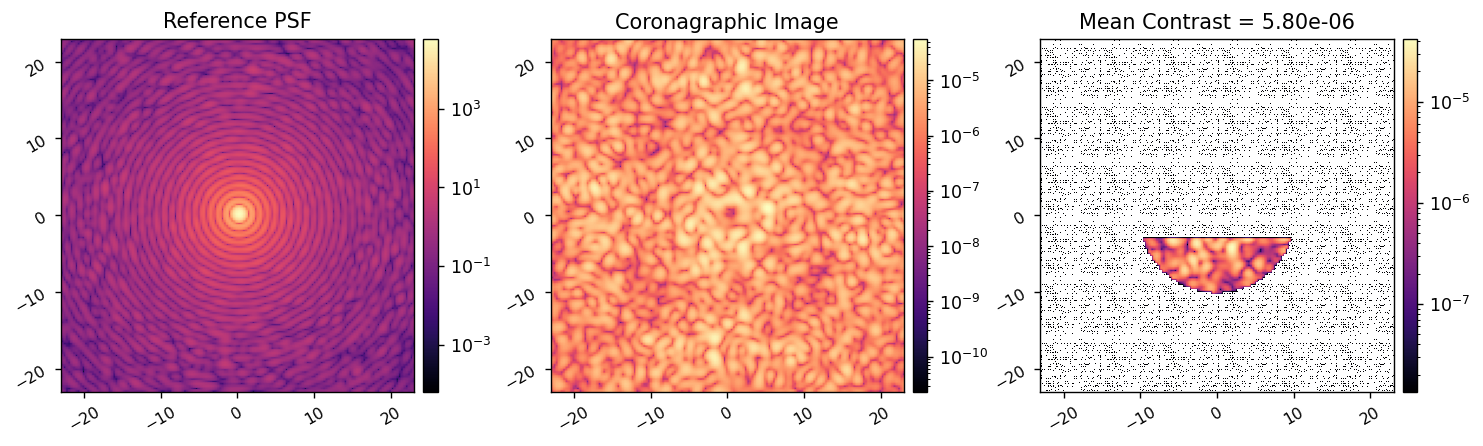

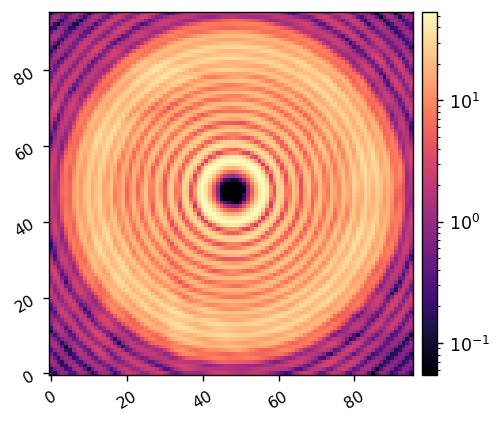

In [24]:
reload(scoobm)
reload(utils)

M = scoobm.single()
M.dm_ref = flat_command + 2.5e-9*xp.random.randn(M.Nact, M.Nact)
M.reset_dm()
M.AMP = wfe_amp
M.OPD = wfe_opd 

iwa = 3
owa = 10
control_mask = utils.create_annular_focal_plane_mask(
    M.ncamsci, 
    M.camsci_pxscl_lamD, 
    iwa, 
    owa,  
    edge=iwa,
    rotation=90,
)

M.use_vortex = 0
ref_psf = M.snap_camsci()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = 1
camsci_im0 = M.snap_camsci()
mean_contrast = xp.mean(camsci_im0[control_mask])

imshow3(
    ref_psf, camsci_im0, camsci_im0*control_mask,
    'Reference PSF', 'Coronagraphic Image', f'Mean Contrast = {mean_contrast:.2e}', 
    pxscl=M.camsci_pxscl_lamDc,
    lognorm=1, 
)

M.llowfsc_defocus = 4.75*u.mm
camlo_im0 = M.snap_camlo()
imshow1(camlo_im0, lognorm=1, vmin=xp.max(camlo_im0)/1e3)

In [25]:
utils.save_fits('dm_flat.fits', M.dm_ref)

Saved data to:  dm_flat.fits
